Iteration	Approximation		Error
1		0.877583		3.775826e-01
2		0.639012		2.385701e-01
3		0.802685		1.636726e-01
4		0.694778		1.079071e-01
5		0.768196		7.341780e-02
6		0.719165		4.903039e-02
7		0.752356		3.319031e-02
8		0.730081		2.227470e-02
9		0.745120		1.503928e-02
10		0.735006		1.011403e-02
11		0.741827		6.820214e-03
12		0.737236		4.590797e-03
13		0.740330		3.093926e-03
14		0.738246		2.083414e-03
15		0.739650		1.403724e-03
16		0.738705		9.454234e-04
17		0.739341		6.369129e-04
18		0.738912		4.290029e-04
19		0.739201		2.889948e-04
20		0.739007		1.946644e-04
21		0.739138		1.311310e-04
22		0.739050		8.833017e-05
23		0.739109		5.950083e-05
24		0.739069		4.008022e-05
25		0.739096		2.699863e-05
26		0.739078		1.818655e-05
27		0.739090		1.225070e-05
28		0.739082		8.252210e-06
29		0.739087		5.558793e-06
30		0.739084		3.744468e-06
31		0.739086		2.522319e-06
32		0.739084		1.699064e-06
33		0.739086		1.144510e-06
34		0.739085		7.709558e-07
35		0.739085		5.193252e-07
36		0.739085		3.498237e-07

Root:

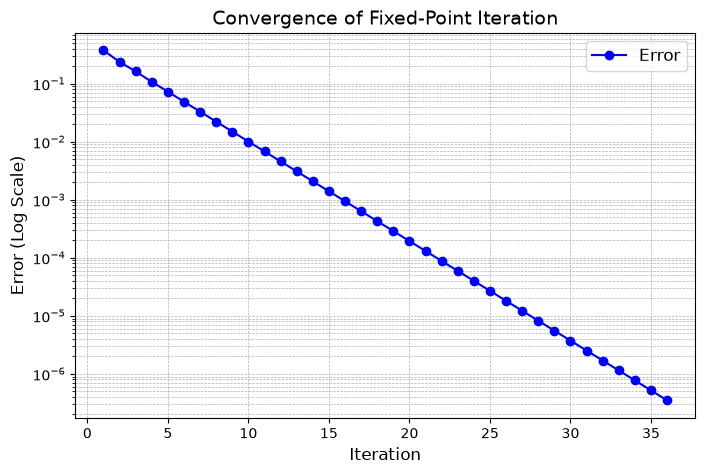

In [ ]:
# Fixed-Point Iteration Method.

import numpy as np  
import matplotlib.pyplot as plt


def fixed_point_iteration(g, x0, tol=0.5e-6, max_iter=100):
    """
    Parameters:
        g (function): Function representing the iteration g(x).
        x0 (float): Initial guess.
        tol (float): Tolerance for stopping criterion.
        max_iter (int): Maximum number of iterations.

    Returns:
        root (float): Approximated root.
        error_table (list): Error and root approximations at each iteration.
    """

    x = x0
    error_table = []

    for i in range(max_iter):
        x_next = g(x)#xn+1=gx
        error = abs(x_next - x)

        error_table.append((i + 1, x_next, error))

        if error < tol:
            return x_next, error_table

        x = x_next

    raise RuntimeError("Maximum iterations exceeded without convergence.")


# Define the function g(x)
# (must be written as x = g(x), x - cos(x) = 0)

def g_example(x):
    return np.cos(x)      # Example: g(x) = cos(x)


# Initial guess
x0_example = 0.5 #bcz root lies in [0,1]


# Solve using fixed-point iteration
root, error_table = fixed_point_iteration(g_example, x0_example)


# Print the results
print("Iteration\tApproximation\t\tError")

for row in error_table:
    print(f"{row[0]}\t\t{row[1]:.6f}\t\t{row[2]:.6e}")

print(f"\nRoot: {root}")


# Plot convergence
iterations = [row[0] for row in error_table]
errors = [row[2] for row in error_table]

plt.figure(figsize=(8, 5))
plt.semilogy(iterations, errors,
             marker='o',
             linestyle='-',
             color='b',
             label='Error')

plt.title("Convergence of Fixed-Point Iteration", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Error (Log Scale)", fontsize=12)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend(fontsize=12)
plt.show()

The root is: 1.5213804244995117

Error Table:
           a         b         c      f(c)     Error
0   1.000000  2.000000  1.500000 -0.125000  0.500000
1   1.500000  2.000000  1.750000  1.609375  0.250000
2   1.500000  1.750000  1.625000  0.666016  0.125000
3   1.500000  1.625000  1.562500  0.252197  0.062500
4   1.500000  1.562500  1.531250  0.059113  0.031250
5   1.500000  1.531250  1.515625 -0.034054  0.015625
6   1.515625  1.531250  1.523438  0.012250  0.007812
7   1.515625  1.523438  1.519531 -0.010971  0.003906
8   1.519531  1.523438  1.521484  0.000622  0.001953
9   1.519531  1.521484  1.520508 -0.005179  0.000977
10  1.520508  1.521484  1.520996 -0.002279  0.000488
11  1.520996  1.521484  1.521240 -0.000829  0.000244
12  1.521240  1.521484  1.521362 -0.000103  0.000122
13  1.521362  1.521484  1.521423  0.000259  0.000061
14  1.521362  1.521423  1.521393  0.000078  0.000031
15  1.521362  1.521393  1.521378 -0.000013  0.000015
16  1.521378  1.521393  1.521385  0.000033  0.000008


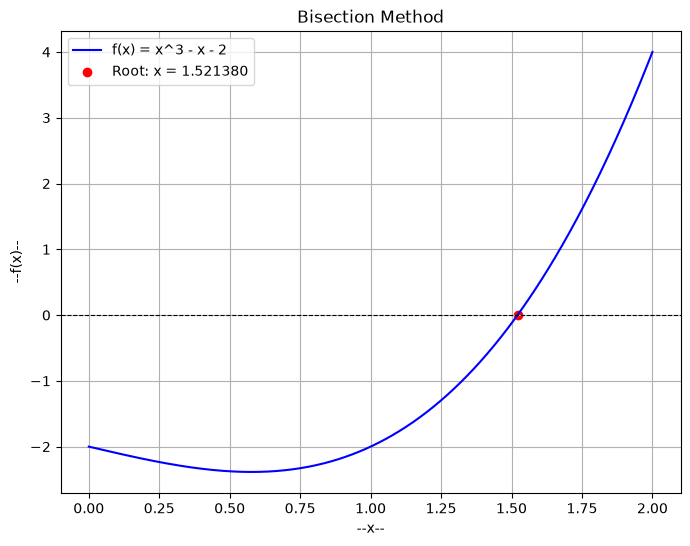

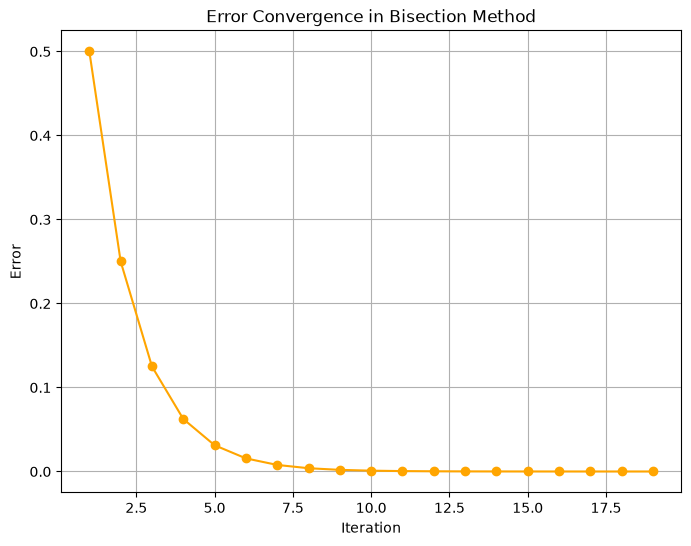

In [ ]:
# Bisection Method Implementation with Error Calculation, Plot, and Error Table

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def bisection_method(func, a, b, tol):

    if func(a) * func(b) >= 0:
        raise ValueError("The function must have opposite signs at a and b.")

    errors = []          # To store error at each step
    iterations = []      # To store iteration details

    while (b - a) / 2 > tol:

        c = (a + b) / 2
        error = abs(b - a) / 2

        errors.append(error)                          # Calculate and store error
        iterations.append((a, b, c, func(c), error)) # Store iteration details

        if func(c) == 0:
            break
        elif func(a) * func(c) < 0:
            b = c
        else:
            a = c

    root = (a + b) / 2
    return root, errors, iterations


# Example Function for Bisection
f = lambda x: x**3 - x - 2


# Call the Bisection Method
root, errors, iterations = bisection_method(f, 1, 2, 1e-6) #1e-e error dea hai hame 6 digit tak dekhna hai
print(f"The root is: {root}")


# Generate an error table
error_table = pd.DataFrame(
    iterations,
    columns=["a", "b", "c", "f(c)", "Error"]
)

print("\nError Table:")
print(error_table)


# Plot the function and the root for Bisection
x = np.linspace(0, 2, 500)
y = f(x)

plt.figure(figsize=(8, 6))
plt.plot(x, y, label='f(x) = x^3 - x - 2', color='blue')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.scatter(root, f(root), color='red', label=f'Root: x = {root:.6f}')

plt.title('Bisection Method')
plt.xlabel('--x--')
plt.ylabel('--f(x)--')
plt.legend()
plt.grid(True)
plt.show()


# Plot Error Convergence for Bisection
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(errors) + 1), errors, marker='o', color='orange')

plt.title('Error Convergence in Bisection Method')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.grid(True)
plt.show()